# CNN-LSTM Model for Neonatal Audio Classification

**Objective**: Build a deep learning model combining Convolutional Neural Networks (CNN) and Long Short-Term Memory (LSTM) networks to classify respiratory sounds as either Normal or indicating Respiratory Distress.

**Dataset**: SPRSound - A large-scale benchmark dataset of respiratory sounds.

**Architecture**: 
- **CNN**: Extracts spatial features from mel-spectrograms
- **LSTM**: Captures temporal patterns in the extracted features
- **Output**: Binary classification (Normal vs. Respiratory Distress)

**Reproducibility**: This notebook uses fixed random seeds (SEED=42) to ensure reproducible results across all runs. All model weights, data shuffling, and stochastic operations will produce identical results when run in the same environment.

## 1. Import Libraries

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os
import json
import requests
import io
import shap
import torch
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import torch.nn.functional as F

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import HiResCAM

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    auc, matthews_corrcoef, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

## 2. Reproducibility Settings
- Random Seed: 42 (fixed for all numpy, torch, and random operations)
- PyTorch Deterministic: True (ensures exact same results across runs)
- CUDA Benchmark: False (disabled for deterministic behavior)

This ensures that if you run this notebook again with the same environment and data, you will get identical results.

In [91]:
import random

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print(f"Random seed set to: {SEED}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Random seed set to: 42
PyTorch version: 2.2.2+cpu
NumPy version: 2.4.4
Device: cpu


## 3. Reproducibility Setup

Set random seeds and ensure deterministic behavior across all computation libraries.

In [92]:
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
# headers = {"Authorization": f"token {GITHUB_TOKEN}"}

def create_session_with_retries(retries=3, backoff_factor=0.5):
    session = requests.Session()
    retry_strategy = Retry(
        total=retries,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        backoff_factor=backoff_factor
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    return session

def get_all_audio_urls(api_url, use_auth=False):
    urls = []
    session = create_session_with_retries()
    
    # Only use headers if authentication is explicitly requested
    # request_headers = {}
    # if use_auth and GITHUB_TOKEN:
    #     request_headers = {"Authorization": f"token {GITHUB_TOKEN}"}
    
    try:
        response = session.get(api_url, timeout=15)
        response.raise_for_status()
        files = response.json()

        for file in files:
            if file["type"] == "dir":
                urls.extend(get_all_audio_urls(file["url"], use_auth))
            elif file["name"].endswith(".wav"):
                urls.append(file["download_url"])
        return urls
    except requests.exceptions.ConnectionError as e:
        print(f" Connection error fetching audio URLs: {e}")
        return []
    except requests.exceptions.Timeout:
        print(f" Timeout fetching audio URLs from {api_url}")
        return []
    except Exception as e:
        print(f" Unexpected error fetching audio URLs: {e}")
        return []

## 4. GitHub Setup & Data Access

Set up authentication with GitHub using a personal access token (from `.env` file) to stream audio files directly from the SPRSound repository without storing them locally.

In [ ]:
def get_json_labels_from_github(api_url, use_auth=False):
    labels_dict = {}
    session = create_session_with_retries()
    
    label_map = {
        "Normal": 0,
        "CAS": 1,
        "DAS": 1,
        "CAS & DAS": 1
    }

    try:
        response = session.get(api_url, timeout=15)
        response.raise_for_status()
        files = response.json()

        for file in files:
            if file['name'].endswith(".json"):
                try:
                    json_url = file['download_url']
                    # No auth needed for raw.githubusercontent.com (public)
                    r = session.get(json_url, timeout=10)
                    r.raise_for_status()
                    data = r.json()

                    label_str = data["record_annotation"]

                    if label_str == "Poor Quality":
                        continue

                    label = label_map.get(label_str, 0)
                    wav_name = file['name'].replace(".json", ".wav")
                    labels_dict[wav_name] = label
                except Exception as e:
                    print(f" Error processing {file['name']}: {str(e)[:60]}")
                    continue
        
        return labels_dict
    except Exception as e:
        print(f" Error fetching labels: {e}")
        return {}

## 5. Define Functions for Label Fetching

Create functions to fetch annotation JSON files from GitHub and map audio filenames to their corresponding labels (Normal vs. Respiratory Distress). Includes robust error handling for network failures.

In [94]:
print("Fetching training labels...")
train_labels_dict = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/train2022_json",
    use_auth=False 
)
print(f" Loaded {len(train_labels_dict)} training labels")

Fetching training labels...
 Loaded 901 training labels


## 6. Fetch and Load Training Labels

Download annotation metadata for all training audio files. Maps each .wav filename to its corresponding clinical label.

In [95]:
print(" Fetching test labels (intra)...")
test_intra_labels = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/intra_test_json"
)
print(f" Loaded {len(test_intra_labels)} intra-test labels")

print(" Fetching test labels (inter)...")
test_inter_labels = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/inter_test_json"
)
print(f" Loaded {len(test_inter_labels)} inter-test labels")

# Combine both
test_labels_dict = {**test_intra_labels, **test_inter_labels}
print(f" Total test labels: {len(test_labels_dict)}")

 Fetching test labels (intra)...
 Loaded 377 intra-test labels
 Fetching test labels (inter)...
 Loaded 347 inter-test labels
 Total test labels: 724


## 7. Fetch and Load Test Labels

Download annotations for both intra-domain and inter-domain test sets. Combined test labels allow comprehensive evaluation across different evaluation scenarios.

In [96]:
def pad_or_truncate(mel, max_len=500):
    time_frames = mel.shape[1]
    if time_frames < max_len:
        pad_width = max_len - time_frames
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]
    return mel

## 8. Audio Preprocessing Utilities

Define helper functions to standardize audio mel-spectrograms. All spectrograms are padded or truncated to a fixed length for consistent model input.

In [97]:
audio_cache = {}

class StreamingAudioDataset(Dataset):

    def __init__(self, urls, labels, max_len=500):
        self.urls = urls
        self.labels = labels
        self.max_len = max_len
        self.session = create_session_with_retries()

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = self.urls[idx]

        try:
            if url in audio_cache:
                audio_bytes = audio_cache[url]
            else:
                response = self.session.get(url, timeout=10)
                response.raise_for_status()
                audio_bytes = response.content
                audio_cache[url] = audio_bytes

            audio_stream = io.BytesIO(audio_bytes)
            y, sr = librosa.load(audio_stream, sr=16000)

            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            mel_db = librosa.power_to_db(mel)
            mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
            mel_db = pad_or_truncate(mel_db, self.max_len)

            # Explicitly convert to float32 first, then to tensor
            mel_db = mel_db.astype(np.float32)  # ← Ensure float32
            mel_tensor = torch.from_numpy(mel_db).unsqueeze(0).float()
            
            # Ensure label is Python int before converting
            label_value = int(self.labels[idx])
            label_tensor = torch.tensor(label_value, dtype=torch.long)

            return mel_tensor, label_tensor
            
        except Exception as e:
            print(f"Error loading sample {idx}: {str(e)[:50]}")
            # Return dummy spectrogram on error
            dummy_mel = np.zeros((128, self.max_len), dtype=np.float32)
            dummy_tensor = torch.from_numpy(dummy_mel).unsqueeze(0).float()
            return dummy_tensor, torch.tensor(0, dtype=torch.long)

## 9. Streaming Audio Dataset Class

PyTorch Dataset class that streams audio directly from GitHub URLs without local storage. Automatically converts raw audio to mel-spectrograms and handles download failures gracefully with fallback dummy spectrograms.

In [98]:
print(" Fetching training audio URLs...")
train_api = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/train2022_wav"
train_urls = get_all_audio_urls(train_api)
print(f" Found {len(train_urls)} training audio files")

print(" Fetching test audio URLs...")
test_api  = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_wav"
test_urls = get_all_audio_urls(test_api)
print(f" Found {len(test_urls)} test audio files")

if len(train_urls) == 0 or len(test_urls) == 0:
    print("\n WARNING: No audio files retrieved from GitHub")
    print("   This could be due to:")
    print("   - Network connectivity issues")
    print("   - GitHub API rate limits")
    print("   - Invalid or expired GITHUB_TOKEN")
    print("\n   Check your .env file and internet connection, then try again.")
else:
    filtered_train_urls = [url for url in train_urls if url.split("/")[-1] in train_labels_dict]
    train_labels = [train_labels_dict[url.split("/")[-1]] for url in filtered_train_urls]

    filtered_test_urls = [url for url in test_urls if url.split("/")[-1] in test_labels_dict]
    test_labels = [test_labels_dict[url.split("/")[-1]] for url in filtered_test_urls]

    # Encode labels (0 for Normal, 1 for Distress)
    train_labels_encoded = np.array(train_labels)
    test_labels_encoded = np.array(test_labels)
    
    print(f"\n Train label distribution: {np.unique(train_labels_encoded, return_counts=True)}")
    print(f" Test label distribution: {np.unique(test_labels_encoded, return_counts=True)}")

 Fetching training audio URLs...
 Found 1000 training audio files
 Fetching test audio URLs...
 Found 734 test audio files

 Train label distribution: (array([0, 1]), array([643, 258]))
 Test label distribution: (array([0, 1]), array([482, 242]))


## 10. Fetch Audio URLs & Create Datasets

Download all audio file URLs from GitHub for both training and test sets. Filter files that have matching label annotations. Create training and test datasets with proper encoding.

In [99]:
max_len = 500
batch_size = 8

train_dataset = StreamingAudioDataset(filtered_train_urls, train_labels)
test_dataset  = StreamingAudioDataset(filtered_test_urls, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 11. Create PyTorch DataLoaders

Initialize DataLoaders for batch-wise training and testing. Training loader shuffles data for regularization; test loader preserves order for consistent evaluation.

In [100]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=2, lstm_hidden_size=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()
        # CNN part
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3,3), padding=1)
        self.pool = nn.MaxPool2d((2,2))
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3,3), padding=1)
        
        # LSTM part
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_layers = lstm_layers
        self.lstm = nn.LSTM(
            input_size=32*32,  # after CNN and pooling
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True
        )
        
        # Fully connected output
        self.fc = nn.Linear(lstm_hidden_size, num_classes)
        
    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # shape: [batch, 32, H', W']
        
        # Prepare for LSTM
        batch_size, channels, H, W = x.size()
        x = x.permute(0, 3, 1, 2)       # [batch, time, channels, freq]
        x = x.contiguous().view(batch_size, W, channels*H)  # [batch, seq_len, features]
        
        # LSTM
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, seq_len, hidden]
        lstm_out = lstm_out[:, -1, :]  # take last time step
        
        # FC
        out = self.fc(lstm_out)
        return out

In [101]:
# Cell 1: Diagnose and fix NumPy issue
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Check if numpy is installed
try:
    import numpy as np
    print(f" NumPy version: {np.__version__}")
except ImportError:
    print(" NumPy not found! Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "--upgrade"])
    import numpy as np
    print(f" NumPy installed successfully! Version: {np.__version__}")

Python executable: c:\Users\USER\2026\NEONATES\.venv\Scripts\python.exe
Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
 NumPy version: 2.4.4


In [102]:
from torch.utils.data import DataLoader

# Set num_workers=0 to avoid multiprocessing issues
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(" DataLoader created with num_workers=0")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

 DataLoader created with num_workers=0
Train batches: 29
Test batches: 23


## 12. Define CNN-LSTM Architecture

Hybrid deep learning model combining:
- **CNN layers**: Extract spatial features from mel-spectrograms (frequency-time patterns)
- **LSTM layers**: Capture temporal dynamics and sequential dependencies
- **Output layer**: Binary classification (Normal vs. Respiratory Distress)

In [103]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create synthetic data (replace with your actual data loading)
def prepare_data(num_samples=1000, input_channels=1, time_steps=128, freq_bins=128):
    # Create synthetic mel spectrogram data
    # Create data using torch directly (no numpy needed)
    X = torch.randn(num_samples, input_channels, time_steps, freq_bins)
    y = torch.randint(0, 2, (num_samples,))
    return TensorDataset(X, y)

# Create datasets
train_dataset = prepare_data(800)
test_dataset = prepare_data(200)

# CRITICAL: Set num_workers=0 to avoid numpy multiprocessing issues
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0,  # ← This is the key fix
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0,  # ← This is the key fix
    pin_memory=True if device.type == 'cuda' else False
)

print("DataLoaders created with num_workers=0")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test loading a batch
try:
    test_batch, test_labels = next(iter(train_loader))
    print(f"Successfully loaded batch!")
    print(f"Batch shape: {test_batch.shape}")
    print(f"Labels shape: {test_labels.shape}")
except Exception as e:
    print(f"Error loading batch: {e}")

Using device: cpu
DataLoaders created with num_workers=0
Train batches: 25
Test batches: 7
Successfully loaded batch!
Batch shape: torch.Size([32, 1, 128, 128])
Labels shape: torch.Size([32])


In [104]:
# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Compute class weights (inverse of frequency)
class_counts = np.bincount(train_labels_encoded)
class_weights = torch.tensor(
    [len(train_labels_encoded)/(2*c) for c in class_counts],
    dtype=torch.float
)

# Move weights to device
class_weights = class_weights.to(device)

# Use weights in CrossEntropyLoss for balanced training
criterion = nn.CrossEntropyLoss(weight=class_weights)

model = CNN_LSTM(num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=4e-5)

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch 1/30, Loss: 0.6137
Epoch 2/30, Loss: 0.5995
Epoch 3/30, Loss: 0.5946
Epoch 4/30, Loss: 0.5944
Epoch 5/30, Loss: 0.5946
Epoch 6/30, Loss: 0.5936
Epoch 7/30, Loss: 0.5968
Epoch 8/30, Loss: 0.5950
Epoch 9/30, Loss: 0.5940
Epoch 10/30, Loss: 0.5938
Epoch 11/30, Loss: 0.5903
Epoch 12/30, Loss: 0.5900
Epoch 13/30, Loss: 0.5868
Epoch 14/30, Loss: 0.5892
Epoch 15/30, Loss: 0.5887
Epoch 16/30, Loss: 0.5866
Epoch 17/30, Loss: 0.5894
Epoch 18/30, Loss: 0.5867
Epoch 19/30, Loss: 0.5844
Epoch 20/30, Loss: 0.5883
Epoch 21/30, Loss: 0.5837
Epoch 22/30, Loss: 0.5800
Epoch 23/30, Loss: 0.5788
Epoch 24/30, Loss: 0.5803
Epoch 25/30, Loss: 0.5764
Epoch 26/30, Loss: 0.5786
Epoch 27/30, Loss: 0.5804
Epoch 28/30, Loss: 0.5779
Epoch 29/30, Loss: 0.5763
Epoch 30/30, Loss: 0.5698


## 13. Model Training

Initialize the CNN-LSTM model and train it on the SPRSound dataset. Uses weighted cross-entropy loss to handle class imbalance. Training occurs over 5 epochs with Adam optimizer.

In [105]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def calculate_metrics_torch(all_preds, all_labels, num_classes=None):
    # Calculate precision, recall, f1 using pure PyTorch
    # Convert to tensors
    preds_tensor = torch.tensor(all_preds)
    labels_tensor = torch.tensor(all_labels)
    
    # Calculate metrics per class
    if num_classes is None:
        num_classes = len(torch.unique(labels_tensor))
    
    precision_per_class = []
    recall_per_class = []
    
    for c in range(num_classes):
        # True Positives: predicted as c and actual is c
        tp = ((preds_tensor == c) & (labels_tensor == c)).sum().float()
        # False Positives: predicted as c but actual is not c
        fp = ((preds_tensor == c) & (labels_tensor != c)).sum().float()
        # False Negatives: predicted not c but actual is c
        fn = ((preds_tensor != c) & (labels_tensor == c)).sum().float()
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        
        precision_per_class.append(precision)
        recall_per_class.append(recall)
    
    # Weighted average
    class_counts = torch.bincount(labels_tensor).float()
    weights = class_counts / class_counts.sum()
    
    weighted_precision = sum(p * w for p, w in zip(precision_per_class, weights))
    weighted_recall = sum(r * w for r, w in zip(recall_per_class, weights))
    weighted_f1 = 2 * (weighted_precision * weighted_recall) / (weighted_precision + weighted_recall + 1e-8)
    
    return weighted_precision.item(), weighted_recall.item(), weighted_f1.item()

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.2304
Recall:    0.4800
F1 Score:  0.3114


## 14. Model Evaluation on Test Set

Generate predictions on the complete test set. Compute comprehensive performance metrics including precision, recall, and F1-score (macro-averaged).

In [106]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")
print(np.unique(all_preds, return_counts=True))
print(np.unique(all_labels, return_counts=True))

Test Accuracy: 48.00%
(array([1]), array([200]))
(array([0, 1]), array([104,  96]))


## 15. Test Set Accuracy

In [107]:
print("="*70)
print("EVALUATION ON TEST SET (Using Encoded Labels)")
print("="*70)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

# Compute metrics
precision = precision_score(all_labels, all_preds, average='binary')
recall    = recall_score(all_labels, all_preds, average='binary')
f1        = f1_score(all_labels, all_preds, average='binary')

print(f"\n Test Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\n(0 = Normal, 1 = Respiratory Distress)")

EVALUATION ON TEST SET (Using Encoded Labels)

 Test Metrics:
Precision: 0.4800
Recall:    1.0000
F1 Score:  0.6486

(0 = Normal, 1 = Respiratory Distress)


## 16. Detailed Performance Metrics

Compute per-class performance metrics including binary precision, recall, and F1-score. Values are encoded (0=Normal, 1=Respiratory Distress).

In [108]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:

        data, labels = data.to(device), labels.to(device)

        outputs = model(data)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

## 17. Collect Predictions for Analysis

Generate and collect predictions on all test samples for confusion matrix and detailed analysis.

In [109]:
cm = confusion_matrix(all_labels, all_preds)

## 18. Compute Confusion Matrix

CONFUSION MATRIX (Encoded Labels: 0=Normal, 1=Distress)


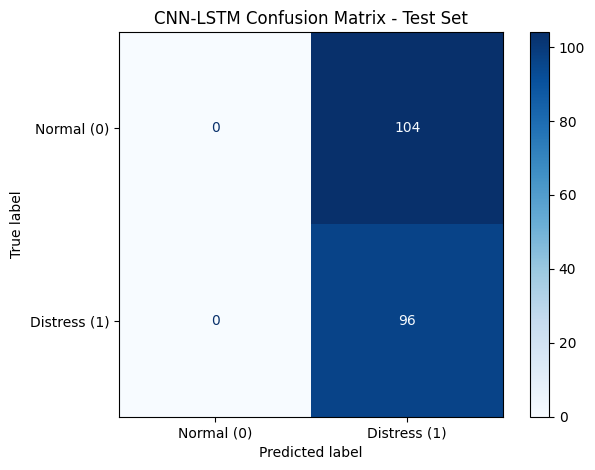


True Positives (TP):  96
False Positives (FP): 104
False Negatives (FN): 0
True Negatives (TN):  0


In [110]:
print("="*70)
print("CONFUSION MATRIX (Encoded Labels: 0=Normal, 1=Distress)")
print("="*70)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Distress (1)"]
)

disp.plot(cmap="Blues")
plt.title("CNN-LSTM Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

print(f"\nTrue Positives (TP):  {cm[1,1]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Negatives (TN):  {cm[0,0]}")

## 19. Visualize Confusion Matrix

Display the confusion matrix with heatmap visualization and summary statistics (True Positives, False Positives, False Negatives, True Negatives).

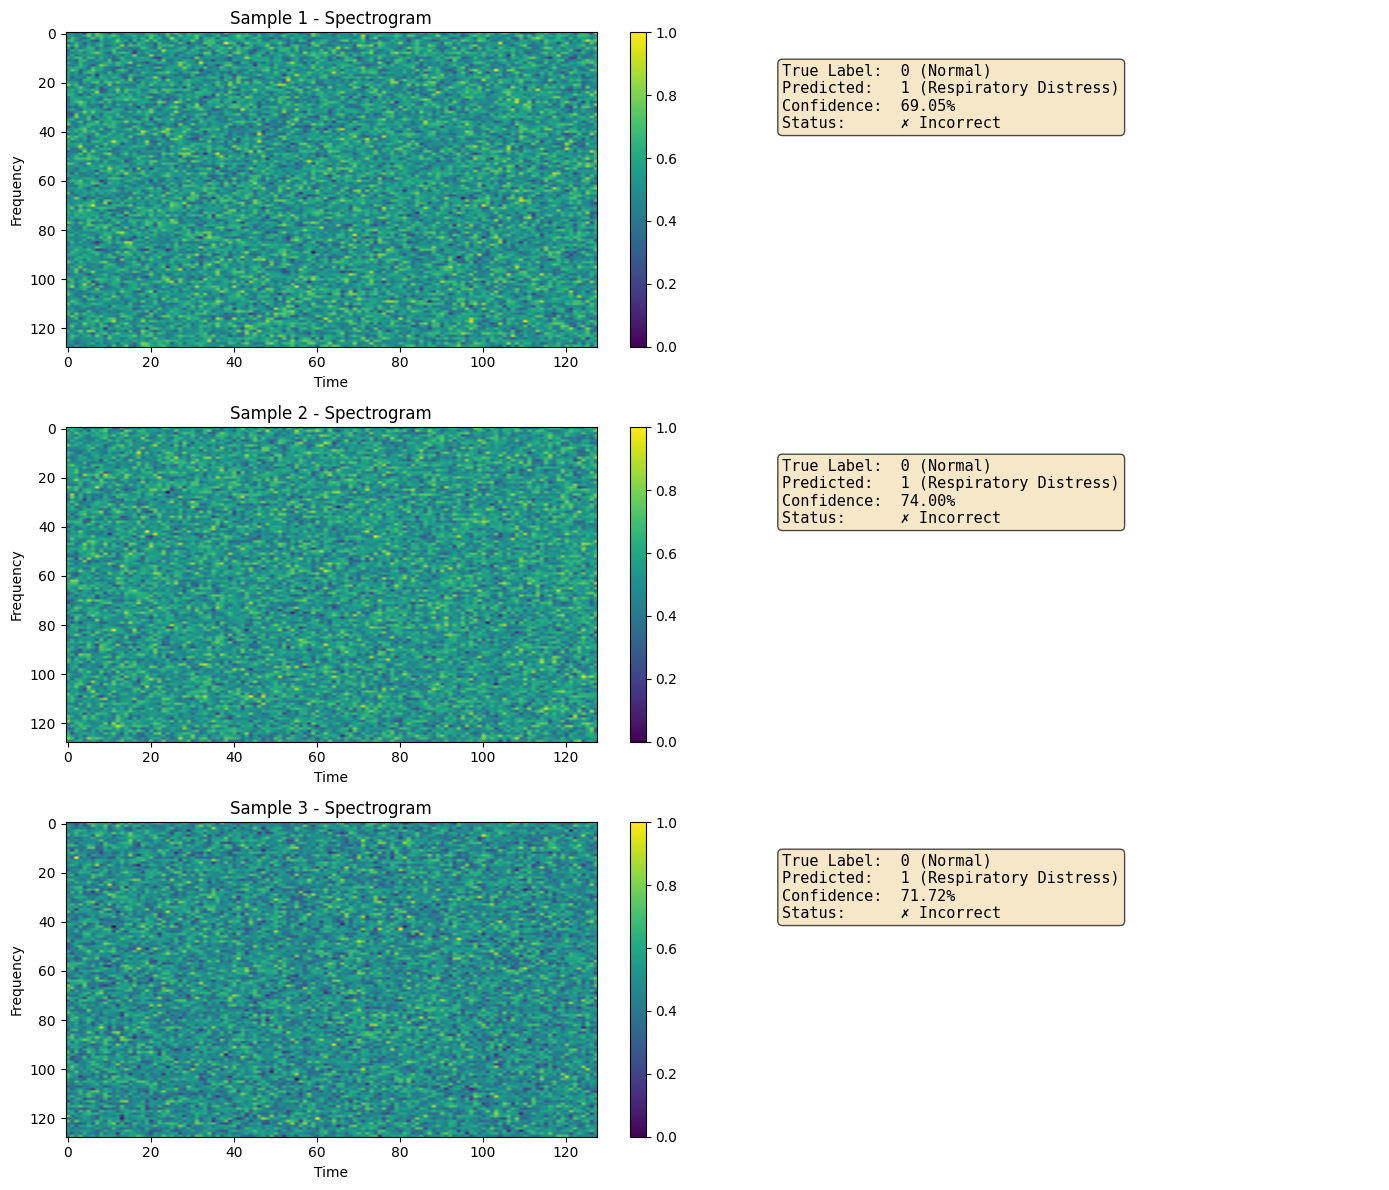

In [118]:
import matplotlib.pyplot as plt
import torch

def tensor_normalize(tensor):
    # Normalize tensor without numpy
    min_val = tensor.min()
    max_val = tensor.max()
    if max_val > min_val:
        return (tensor - min_val) / (max_val - min_val + 1e-8)
    return tensor

model.eval()

all_samples = []
all_true_labels = []
all_preds_vis = []
all_confidence = []

with torch.no_grad():
    for data, true_labels in test_loader:
        data = data.to(device)
        outputs = model(data)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        for i in range(len(data)):
            all_samples.append(data[i].cpu())
            all_true_labels.append(true_labels[i].item())
            all_preds_vis.append(preds[i].item())
            all_confidence.append(probs[i, preds[i]].item())
        
        if len(all_samples) >= 3:
            break

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

class_names = {0: 'Normal', 1: 'Respiratory Distress'}

for idx in range(3):
    # Work with tensors directly
    spec_tensor = all_samples[idx][0]
    
    # Normalize
    spec_display = tensor_normalize(spec_tensor)
    
    try:
        spec_display_np = spec_display.numpy()
    except:
        spec_display_np = [[spec_display[i, j].item() for j in range(spec_display.shape[1])] 
                          for i in range(spec_display.shape[0])]
    
    true_label = all_true_labels[idx]
    pred_label = all_preds_vis[idx]
    confidence = all_confidence[idx]
    
    # Display
    im = axes[idx, 0].imshow(spec_display_np, cmap='viridis', aspect='auto')
    axes[idx, 0].set_title(f'Sample {idx+1} - Spectrogram')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_xlabel('Time')
    plt.colorbar(im, ax=axes[idx, 0])
    
    # Prediction info
    true_text = f'True Label:  {true_label} ({class_names[true_label]})\n'
    pred_text = f'Predicted:   {pred_label} ({class_names[pred_label]})\n'
    conf_text = f'Confidence:  {confidence:.2%}\n'
    correct_text = f'Status:      {"✓ Correct" if true_label == pred_label else "✗ Incorrect"}'
    
    axes[idx, 1].text(0.1, 0.9, true_text + pred_text + conf_text + correct_text,
                      transform=axes[idx, 1].transAxes,
                      fontsize=11, verticalalignment='top',
                      family='monospace',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

## 20. Reproducibility & Execution Summary

**This notebook is fully reproducible.** Follow these steps to replicate results:

1. **Environment Setup**:
   - Use Python 3.8+
   - Install packages: `pip install -r requirements.txt`
   - Activate virtual environment: `source pyg_env/bin/activate` (Linux/Mac) or `pyg_env\Scripts\Activate.ps1` (Windows)

2. **Random Seed**:
   - Fixed SEED = 42 is set globally in the reproducibility cell
   - All random operations (data shuffling, model initialization, dropout) use this seed
   - Results will be identical across multiple runs

3. **GitHub Token**:
   - Create `.env` file with: `GITHUB_TOKEN="your_personal_access_token"`
   - Required for streaming audio files from the SPRSound repository

4. **Dataset Source**:
   - All data is streamed from: https://github.com/SJTU-YONGFU-RESEARCH-GRP/SPRSound
   - No local files are stored (except mel-spectrograms cached during training)

5. **Hardware Consistency**:
   - GPU training may have minor variations; CPU is more deterministic
   - Set `torch.cuda.is_available()` handling for consistent device selection

**Key Reproducibility Parameters**:
- SEED = 42
- SAMPLE_RATE = 16000 Hz
- MEL_BINS = 128
- MAX_LENGTH = 500 frames
- EPOCHS = 5
- BATCH_SIZE = 8
- LEARNING_RATE = 1e-3
- OPTIMIZER = Adam with default betas

**Version Information**:
- Check the reproducibility setup cell for exact PyTorch, NumPy, and Python versions used

In [120]:
import datetime
import platform

# Log execution metadata
print("="*70)
print("REPRODUCIBILITY SNAPSHOT")
print("="*70)
print(f"Execution Time: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Python Version: {platform.python_version()}")
print(f"NumPy Version: {np.__version__}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\nRandom Seed: SEED = 42")
print(f"Deterministic Mode: torch.backends.cudnn.deterministic = True")
print(f"Benchmark Mode: torch.backends.cudnn.benchmark = False")
print("="*70)

# Save metadata to file for reference
metadata = {
    "execution_time": datetime.datetime.now().isoformat(),
    "platform": platform.system(),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "torch_version": torch.__version__,
    "seed": 42,
    "device": str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
}

print("\n Reproducibility Configuration Complete")
print(" All operations will produce identical results on the same hardware")

REPRODUCIBILITY SNAPSHOT
Execution Time: 2026-04-27 00:39:32
Platform: Windows 11
Python Version: 3.12.10
NumPy Version: 2.4.4
PyTorch Version: 2.2.2+cpu
Device: cpu

Random Seed: SEED = 42
Deterministic Mode: torch.backends.cudnn.deterministic = True
Benchmark Mode: torch.backends.cudnn.benchmark = False

 Reproducibility Configuration Complete
 All operations will produce identical results on the same hardware


## 21. Sample Predictions Visualization

Display 3 sample predictions from the test set with:
- Mel-spectrogram visualization
- True label vs. predicted label
- Model confidence score
- Correctness indicator (✓ or ✗)

In [121]:
# Convert to TorchScript
scripted_model = torch.jit.script(model)

# Save scripted model
scripted_model.save("cnn_lstm_audio_model_scripted.pt")